# Imported Inflation Analysis in Mauritania

This notebook analyses imported inflation in Mauritania using the National Consumer Price Index (INPC), the import Unit Value Index (UVI), the USD/MRU exchange rate and detailed Level 2 import categories. The methodology and numerical results are preserved exactly from the original graduation project.

## 1. Environment and libraries

Import the libraries used for data processing, econometrics, machine learning and visualisation.

In [1]:
# %% Cell 0
# ============================================================
# 0. Complete project: INPC + UVI + exchange rate + DLM score + ARIMAX/SARIMAX + ML
# ============================================================

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:,.6f}".format)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project paths and parameters

Define private input files, public output folders and the original methodological parameters. Institutional data are expected locally in `data/private/` and are not published.

In [2]:
# Project-relative paths and original parameters
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
PRIVATE_DATA_DIR = PROJECT_ROOT / "data" / "private"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

def find_file(file_name, directories=(PRIVATE_DATA_DIR,)):
    for directory in directories:
        output_path = directory / file_name
        if output_path.exists():
            return output_path
    return None

inpc_filename = "Historique_INPC_base_2019_Etude inflation-2025.xlsx"
uvi_filename = "IndiceMensuel base 100=2024.xlsx"
exchange_rate_filename = "coellecte taux_de_change_Najeeb.xlsx"
import_filename_1 = "data (21).xlsx"
import_filename_2 = "data (22).xlsx"

inpc_file = find_file(inpc_filename)
uvi_file = find_file(uvi_filename)
exchange_rate_file = find_file(exchange_rate_filename)
import_file_1 = find_file(import_filename_1)
import_file_2 = find_file(import_filename_2)

files = {"INPC": inpc_file, "UVI": uvi_file, "Exchange rate": exchange_rate_file, "Import file 1": import_file_1, "Import file 2": import_file_2}
for label, file_path in files.items():
    print(f"{label:16s} =>", "OK" if file_path else "MISSING")
missing_files = [label for label, file_path in files.items() if file_path is None]
if missing_files:
    raise FileNotFoundError("Missing private institutional files: " + ", ".join(missing_files) + "\nPlace them locally in data/private/. They are intentionally excluded from GitHub.")

LEVEL2_COLUMN = "Niveau2"
DLM_MAX_LAG = 6
MACRO_MAX_LAG = 3
MIN_AVAILABLE_MONTHS = 36
MIN_VALID_CHANGES = 36
MIN_MODEL_OBSERVATIONS = 36
SIGNIFICANCE_THRESHOLD = 0.10
MAX_IMPORTANCE_RANK = 30
TEST_START_DATE = pd.Timestamp("2025-01-01")
FINAL_TOP_N = 10
SELECTION_METRIC = "RMSE_inflation"
OUTPUTS_DIR = FIGURES_DIR
print("Original project parameters loaded.")

INPC             => OK
UVI              => OK
Exchange rate    => OK
Import file 1    => OK
Import file 2    => OK
Original project parameters loaded.


## 3. Utility functions

Define the original date-conversion, evaluation and INPC-reconstruction functions.

In [3]:
# %% Cell 2
# ============================================================
# 2. Utility functions
# ============================================================

def parse_monthly_column(col):
    """Convert a column such as 2020M1 to Timestamp 2020-01-01."""
    col = str(col).strip()
    match = re.match(r"^(\d{4})M(\d{1,2})$", col)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return pd.Timestamp(year=year, month=month, day=1)
    return None


def convert_excel_or_standard_dates(series):
    """Convert a series that may contain numeric Excel dates or standard dates."""
    dates = pd.to_datetime(series, errors="coerce")
    nums = pd.to_numeric(series, errors="coerce")
    mask = dates.isna() & nums.notna()
    if mask.any():
        dates.loc[mask] = pd.to_datetime(nums.loc[mask], unit="D", origin="1899-12-30", errors="coerce")
    return dates


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def reconstruct_inpc(starting_inpc, predicted_inflation):
    values = []
    previous_inpc = float(starting_inpc)
    for infl in predicted_inflation:
        new_inpc = previous_inpc * np.exp(float(infl) / 100)
        values.append(new_inpc)
        previous_inpc = new_inpc
    return np.array(values)


def r2_correlation(y_true, y_pred):
    """Non-negative R2 used in the presentation: R2 = corr(actual y, predicted y)^2."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)


def calculate_metrics(y_test, y_pred, actual_inpc, inpc_pred):
    """Compute performance metrics for inflation and reconstructed INPC."""
    y_test = np.asarray(y_test, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    actual_inpc = np.asarray(actual_inpc, dtype=float)
    inpc_pred = np.asarray(inpc_pred, dtype=float)

    mae_inflation = mean_absolute_error(y_test, y_pred)
    rmse_inflation = rmse(y_test, y_pred)
    mape_inflation = mape(y_test, y_pred)
    r2_inflation = r2_correlation(y_test, y_pred)

    mae_inpc = mean_absolute_error(actual_inpc, inpc_pred)
    rmse_inpc = rmse(actual_inpc, inpc_pred)
    mape_inpc = mape(actual_inpc, inpc_pred)
    accuracy_inpc = 100 - mape_inpc if pd.notna(mape_inpc) else np.nan
    r2_inpc = r2_correlation(actual_inpc, inpc_pred)

    return {
        "MAE_inflation": mae_inflation,
        "RMSE_inflation": rmse_inflation,
        "MAPE_inflation_%": mape_inflation,
        "R2_inflation": r2_inflation,
        "MAE_INPC": mae_inpc,
        "RMSE_INPC": rmse_inpc,
        "MAPE_INPC_%": mape_inpc,
        "Accuracy_INPC_%": accuracy_inpc,
        "R2_INPC": r2_inpc,
    }

def display_and_save(df, table_name):
    display(public_table(df))
    output_path = TABLES_DIR / f"{table_name}.xlsx"
    public_table(df).to_excel(output_path, index=False)
    print("Saved:", output_path)

print("Utility functions ready.")

PUBLIC_COLUMN_NAMES = {'Niveau2': 'Level 2 category', 'economic_score_rank': 'Economic score rank', 'economic_score': 'Economic score', 'economic_score_x1000': 'Economic score × 1,000', 'beta_0': 'Immediate effect (β0)', 'cumulative_beta': 'Cumulative effect (β)', 'import_value_share': 'Import value share', 'import_value_share_%': 'Import value share (%)', 'main_lag': 'Main lag (months)', 'joint_test_p_value': 'Joint-test p-value', 'adjusted_r2': 'Adjusted R²', 'model': 'Model', 'model_family': 'Model family', 'training_observations': 'Training observations', 'test_observations': 'Test observations', 'MAPE_%': 'MAPE (%)'}
MODEL_LABELS_EN = {'ARIMAX_UVI_EXCHANGE': 'ARIMAX', 'SARIMAX_UVI_EXCHANGE': 'SARIMAX', 'Gradient_Boosting_UVI_EXCHANGE': 'Gradient Boosting', 'Random_Forest_UVI_EXCHANGE': 'Random Forest', 'Elastic_Net_UVI_EXCHANGE': 'Elastic Net', 'Ridge_UVI_EXCHANGE': 'Ridge', 'Lasso_UVI_EXCHANGE': 'Lasso'}

def translate_level2_label(value):
    text = str(value)
    mapping = {
        "Combustibles minéraux": "Mineral fuels, lubricants and related materials",
        "Céréales non transformées": "Unprocessed cereals",
        "Produits pétroliers raffinés": "Refined petroleum products",
        "Huiles et graisses animale": "Animal oils and fats",
        "Viandes et ses préparations": "Meat and meat preparations",
        "Produits chimiques organiques": "Organic chemicals",
        "Laits et produits laitiers": "Milk and dairy products",
        "Fer, fonte et acier": "Iron, cast iron and steel",
        "Sucre et sucrerie": "Sugar and confectionery",
        "Matières et ouvrages plastiques": "Plastics and plastic products",
    }
    for prefix, translated in mapping.items():
        if text.startswith(prefix):
            return translated
    return text

def public_table(df):
    result = df.copy()
    if "Niveau2" in result.columns:
        result["Niveau2"] = result["Niveau2"].map(translate_level2_label)
    if "model" in result.columns:
        result["model"] = result["model"].replace(MODEL_LABELS_EN)
    if "model_family" in result.columns:
        result["model_family"] = result["model_family"].replace({"Statistical": "Statistical", "Machine Learning": "Machine Learning"})
    return result.rename(columns=PUBLIC_COLUMN_NAMES)


Utility functions ready.


## 4. National Consumer Price Index (INPC)

Load and prepare the national monthly INPC series and compute monthly inflation.

In [4]:
# %% Cell 3
# ============================================================
# 3. Load and prepare the overall INPC
# ============================================================

inpc_raw = pd.read_excel(inpc_file, sheet_name="Indices-INPC", header=1)
inpc_raw.columns = [c.strip() if isinstance(c, str) else c for c in inpc_raw.columns]

inpc_row = inpc_raw[inpc_raw["CODE"].astype(str).str.strip() == "INDICE GLOBAL"]
if len(inpc_row) != 1:
    raise ValueError("The CODE = INDICE GLOBAL row is not unique or does not exist.")
inpc_row = inpc_row.iloc[0]

inpc_date_columns = []
for col in inpc_raw.columns:
    parsed_date = pd.to_datetime(col, errors="coerce")
    if not pd.isna(parsed_date):
        inpc_date_columns.append(col)

inpc = inpc_row[inpc_date_columns].reset_index()
inpc.columns = ["date", "INPC_global"]
inpc["date"] = pd.to_datetime(inpc["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
inpc["INPC_global"] = pd.to_numeric(inpc["INPC_global"], errors="coerce")
inpc = inpc.dropna(subset=["date", "INPC_global"]).sort_values("date").reset_index(drop=True)
inpc["monthly_inflation"] = 100 * (np.log(inpc["INPC_global"]) - np.log(inpc["INPC_global"].shift(1)))

print("INPC prepared")
print("INPC period:", inpc["date"].min(), "to", inpc["date"].max())
print("Number of INPC observations:", len(inpc))

INPC prepared
INPC period: 2019-01-01 00:00:00 to 2025-12-01 00:00:00
Number of INPC observations: 84


## 5. Import Unit Value Index (UVI)

Load and prepare the monthly UVI series and its logarithmic variation.

In [5]:
# %% Cell 4
# ============================================================
# 4. Load and prepare the overall UVI
# ============================================================

uvi_raw = pd.read_excel(uvi_file, sheet_name="Feuille1", header=1)
uvi_raw.columns = [str(c).strip() if not pd.isna(c) else f"col_{i}" for i, c in enumerate(uvi_raw.columns)]

uvi_date_columns = [col for col in uvi_raw.columns if parse_monthly_column(col) is not None]
if len(uvi_date_columns) == 0:
    raise ValueError("No monthly UVI column in the 2020M1 format was detected.")

uvi_code_column = uvi_raw.columns[0]
uvi_label_column = "SHPay"

uvi_row = uvi_raw[uvi_raw[uvi_label_column].astype(str).str.strip().str.lower() == "total"]
if len(uvi_row) == 0:
    uvi_row = uvi_raw[uvi_raw[uvi_code_column].astype(str).str.strip().str.upper() == "SH06"]
if len(uvi_row) != 1:
    raise ValueError("The overall UVI Total / SH06 row is not unique or does not exist.")
uvi_row = uvi_row.iloc[0]

uvi = uvi_row[uvi_date_columns].reset_index()
uvi.columns = ["period", "UVI_global"]
uvi["date"] = uvi["period"].apply(parse_monthly_column)
uvi["UVI_global"] = pd.to_numeric(uvi["UVI_global"], errors="coerce")
uvi = uvi.dropna(subset=["date", "UVI_global"])[["date", "UVI_global"]].sort_values("date").reset_index(drop=True)
uvi["uvi_change"] = 100 * (np.log(uvi["UVI_global"]) - np.log(uvi["UVI_global"].shift(1)))

print("UVI prepared")
print("UVI period:", uvi["date"].min(), "to", uvi["date"].max())
print("Number of UVI observations:", len(uvi))

UVI prepared
UVI period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of UVI observations: 69


## 6. USD/MRU exchange rate

Load and aggregate the exchange-rate series at monthly frequency.

In [6]:
# %% Cell 5
# ============================================================
# 5. Load and prepare the USD/MRU exchange rate
# ============================================================

exchange_rate_raw = pd.read_excel(exchange_rate_file, sheet_name="Saisie_Changes", header=None)

# Excel row 329 => Python index 328; columns L:M => indices 11 and 12
exchange_rate_block = exchange_rate_raw.iloc[328:, [11, 12]].copy()
exchange_rate_block.columns = ["date", "usd_mru_rate"]

exchange_rate_block["date"] = convert_excel_or_standard_dates(exchange_rate_block["date"])
exchange_rate_block["usd_mru_rate"] = pd.to_numeric(exchange_rate_block["usd_mru_rate"], errors="coerce")

# Fallback: if the L:M range is empty in another file version, try A:B
if exchange_rate_block.dropna(subset=["date", "usd_mru_rate"]).empty:
    print("Warning: the L:M range is empty. Attempting to read A:B.")
    exchange_rate_block = exchange_rate_raw.iloc[328:, [0, 1]].copy()
    exchange_rate_block.columns = ["date", "usd_mru_rate"]
    exchange_rate_block["date"] = convert_excel_or_standard_dates(exchange_rate_block["date"])
    exchange_rate_block["usd_mru_rate"] = pd.to_numeric(exchange_rate_block["usd_mru_rate"], errors="coerce")

exchange_rate_block = exchange_rate_block.dropna(subset=["date", "usd_mru_rate"]).copy()
exchange_rate_block["date"] = exchange_rate_block["date"].dt.to_period("M").dt.to_timestamp()

# If several values occur within the same month, use the monthly average
monthly_exchange_rate = (
    exchange_rate_block.groupby("date", as_index=False)["usd_mru_rate"]
    .mean()
    .sort_values("date")
    .reset_index(drop=True)
)

monthly_exchange_rate["exchange_rate_change"] = 100 * (
    np.log(monthly_exchange_rate["usd_mru_rate"]) - np.log(monthly_exchange_rate["usd_mru_rate"].shift(1))
)

print("Exchange rate prepared")
print("Exchange-rate period:", monthly_exchange_rate["date"].min(), "to", monthly_exchange_rate["date"].max())
print("Number of exchange-rate observations:", len(monthly_exchange_rate))

Exchange rate prepared
Exchange-rate period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of exchange-rate observations: 69


## 7. Common macroeconomic dataset

Merge INPC, UVI and exchange-rate data and create the original lagged variables.

In [7]:
# %% Cell 6
# ============================================================
# 6. Common INPC-UVI-exchange-rate macroeconomic dataset
# ============================================================

base_macro = (
    inpc[["date", "INPC_global", "monthly_inflation"]]
    .merge(uvi[["date", "UVI_global", "uvi_change"]], on="date", how="inner")
    .merge(monthly_exchange_rate[["date", "usd_mru_rate", "exchange_rate_change"]], on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

print("Common macroeconomic period:", base_macro["date"].min(), "to", base_macro["date"].max())
print("Number of common observations:", len(base_macro))

base_macro["inflation_lag1"] = base_macro["monthly_inflation"].shift(1)
base_macro["inflation_lag12"] = base_macro["monthly_inflation"].shift(12)

features_macro = []
for lag in range(MACRO_MAX_LAG + 1):
    uvi_feature = f"uvi_change_lag{lag}"
    exchange_rate_feature = f"exchange_rate_change_lag{lag}"
    base_macro[uvi_feature] = base_macro["uvi_change"].shift(lag)
    base_macro[exchange_rate_feature] = base_macro["exchange_rate_change"].shift(lag)
    features_macro.extend([uvi_feature, exchange_rate_feature])

base_macro_model = base_macro.dropna(subset=["INPC_global", "monthly_inflation"] + features_macro).copy()

print("Macroeconomic dataset after lag creation:", base_macro_model.shape)
print("Macroeconomic features:", features_macro)

Common macroeconomic period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of common observations: 69
Macroeconomic dataset after lag creation: (65, 17)
Macroeconomic features: ['uvi_change_lag0', 'exchange_rate_change_lag0', 'uvi_change_lag1', 'exchange_rate_change_lag1', 'uvi_change_lag2', 'exchange_rate_change_lag2', 'uvi_change_lag3', 'exchange_rate_change_lag3']


## 8. Detailed import data preparation

Prepare Level 2 import records for the distributed lag analysis without displaying raw institutional rows.

In [8]:
# %% Cell 7
# ============================================================
# 7. Prepare Level 2 imports for DLM analysis
# ============================================================

common_start_date = max(inpc["date"].min(), uvi["date"].min())
common_end_date = min(inpc["date"].max(), uvi["date"].max())

print("Common period used for Level 2 categories:", common_start_date, "to", common_end_date)

# Optimized loading: read only the columns required for the DLM analysis.
# Use local CSV cache files, when available, to speed up execution.
required_import_columns = [
    "DateLiquid1 - Année", "PERIOD", LEVEL2_COLUMN,
    "VALEUR", "POIDSNET", "Type", "TYYPE"
]

cache_import_1 = PRIVATE_DATA_DIR / "test_cache21.csv"
cache_import_2 = PRIVATE_DATA_DIR / "_cache_import_2.csv"

if cache_import_1.exists() and cache_import_2.exists():
    print("Fast loading from local CSV cache.")
    df1 = pd.read_csv(cache_import_1, usecols=lambda c: str(c).strip() in required_import_columns)
    df2 = pd.read_csv(cache_import_2, usecols=lambda c: str(c).strip() in required_import_columns)
else:
    print("Loading from private Excel files. This step may take a few minutes.")
    df1 = pd.read_excel(import_file_1, sheet_name="Export", usecols=lambda c: str(c).strip() in required_import_columns)
    df2 = pd.read_excel(import_file_2, sheet_name="Export", usecols=lambda c: str(c).strip() in required_import_columns)

imports = pd.concat([df1, df2], ignore_index=True)
imports.columns = imports.columns.astype(str).str.strip()

technical_row_pattern = r"^\s*total\s*$|applied filters|grand total"
technical_row_mask = imports.astype(str).apply(
    lambda col: col.str.contains(technical_row_pattern, case=False, na=False, regex=True)
).any(axis=1)
imports = imports.loc[~technical_row_mask].copy()

imports_clean = imports.copy()
imports_clean["year"] = pd.to_numeric(imports_clean["DateLiquid1 - Année"], errors="coerce")
imports_clean["month"] = pd.to_numeric(imports_clean["PERIOD"], errors="coerce")
imports_clean["VALEUR"] = pd.to_numeric(imports_clean["VALEUR"], errors="coerce")
imports_clean["POIDSNET"] = pd.to_numeric(imports_clean["POIDSNET"], errors="coerce")
imports_clean[LEVEL2_COLUMN] = imports_clean[LEVEL2_COLUMN].astype(str).str.strip()

imports_clean = imports_clean.dropna(subset=["year", "month"]).copy()
imports_clean["date"] = pd.to_datetime(
    imports_clean["year"].astype(int).astype(str) + "-" +
    imports_clean["month"].astype(int).astype(str).str.zfill(2) + "-01"
)
imports_clean["date"] = imports_clean["date"].dt.to_period("M").dt.to_timestamp()
imports_clean["period"] = imports_clean["date"].dt.to_period("M").astype(str)

imports_clean = imports_clean[
    (imports_clean["date"] >= common_start_date) &
    (imports_clean["date"] <= common_end_date)
].copy()

imports_clean = imports_clean[
    (imports_clean["Type"].astype(str).str.strip().str.lower() == "importation") |
    (imports_clean["TYYPE"].astype(str).str.strip().str.upper() == "I")
].copy()

imports_clean = imports_clean.dropna(subset=[LEVEL2_COLUMN, "VALEUR", "POIDSNET"]).copy()
imports_clean = imports_clean[(imports_clean["VALEUR"] > 0) & (imports_clean["POIDSNET"] > 0)].copy()
imports_clean = imports_clean[~imports_clean[LEVEL2_COLUMN].str.lower().isin(["", "nan", "none", "total", "grand total"])].copy()

print("Clean import dataset shape:", imports_clean.shape)
print("Clean import dataset period:", imports_clean["date"].min(), "to", imports_clean["date"].max())
print("Number of Level 2 categories:", imports_clean[LEVEL2_COLUMN].nunique())

Common period used for Level 2 categories: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Loading from private Excel files. This step may take a few minutes.
Clean import dataset shape: (164737, 11)
Clean import dataset period: 2020-01-01 00:00:00 to 2025-09-01 00:00:00
Number of Level 2 categories: 124


## 9. Monthly aggregation by Level 2 category

Aggregate import value and net weight, compute unit prices and prepare the DLM input matrix.

In [9]:
# %% Cell 8
# ============================================================
# 8. Monthly Level 2 aggregation and DLM preparation
# ============================================================

common_inpc = inpc[(inpc["date"] >= common_start_date) & (inpc["date"] <= common_end_date)].copy()

level2_monthly = (
    imports_clean
    .groupby(["date", "period", LEVEL2_COLUMN], as_index=False)
    .agg(
        total_value=("VALEUR", "sum"),
        total_net_weight=("POIDSNET", "sum"),
        row_count=("VALEUR", "size")
    )
)
level2_monthly["unit_price"] = level2_monthly["total_value"] / level2_monthly["total_net_weight"]

observations_by_level2 = level2_monthly.groupby(LEVEL2_COLUMN)["period"].nunique().sort_values(ascending=False)
valid_level2_categories = observations_by_level2[observations_by_level2 >= MIN_AVAILABLE_MONTHS].index.tolist()
filtered_level2_monthly = level2_monthly[level2_monthly[LEVEL2_COLUMN].isin(valid_level2_categories)].copy()

unit_price_wide = filtered_level2_monthly.pivot(index="date", columns=LEVEL2_COLUMN, values="unit_price").sort_index()
inpc_ts = common_inpc.set_index("date").sort_index()
base_model = inpc_ts.join(unit_price_wide, how="inner")

level2_columns = [col for col in base_model.columns if col not in ["INPC_global", "monthly_inflation"]]
import_prices = base_model[level2_columns].copy()

# Winsorization to limit the effect of extreme values
winsorized_import_prices = import_prices.copy()
for col in winsorized_import_prices.columns:
    q01 = winsorized_import_prices[col].quantile(0.01)
    q99 = winsorized_import_prices[col].quantile(0.99)
    winsorized_import_prices[col] = winsorized_import_prices[col].clip(lower=q01, upper=q99)

price_changes = 100 * (np.log(winsorized_import_prices) - np.log(winsorized_import_prices.shift(1)))
data_dlm = pd.concat([base_model[["INPC_global", "monthly_inflation"]], price_changes], axis=1)
valid_change_counts = price_changes.notna().sum()
categories_to_test = valid_change_counts[valid_change_counts >= MIN_VALID_CHANGES].index.tolist()

# Import weights
import_weights = (
    imports_clean.groupby(LEVEL2_COLUMN, as_index=False)["VALEUR"].sum()
    .rename(columns={"VALEUR": "import_value"})
)
import_weights["import_value_share"] = import_weights["import_value"] / import_weights["import_value"].sum()
import_weights = import_weights.sort_values("import_value_share", ascending=False).reset_index(drop=True)
import_weights["importance_rank"] = np.arange(1, len(import_weights) + 1)

print("Number of categories to test:", len(categories_to_test))
print("DLM dataset shape:", data_dlm.shape)

Number of categories to test: 91
DLM dataset shape: (69, 100)


## 10. Distributed Lag Models and economic score

Estimate one DLM per eligible category and rank selected categories using the original economic-score formula.

In [10]:
# %% Cell 9
# ============================================================
# 9. Estimate DLM models by Level 2 category and rank by economic score
# ============================================================

def estimate_dlm_for_category(data, category, k=6):
    df = pd.DataFrame(index=data.index)
    df["y"] = data["monthly_inflation"]
    df["x"] = data[category]
    df["y_lag1"] = df["y"].shift(1)

    lagged_x_variables = []
    for lag in range(k + 1):
        column_name = f"x_lag{lag}"
        df[column_name] = df["x"].shift(lag)
        lagged_x_variables.append(column_name)

    df_model = df.dropna().copy()
    if len(df_model) < 20:
        return None, None

    y = df_model["y"]
    X = sm.add_constant(df_model[["y_lag1"] + lagged_x_variables])
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": k})
    coefficients = model.params[lagged_x_variables]

    beta_0 = coefficients["x_lag0"]
    cumulative_beta = coefficients.sum()
    main_lag = int(coefficients.abs().idxmax().replace("x_lag", ""))

    parameter_names = list(model.params.index)
    R = np.zeros((len(lagged_x_variables), len(model.params)))
    for i, var in enumerate(lagged_x_variables):
        R[i, parameter_names.index(var)] = 1
    joint_test = model.wald_test(R, scalar=True)

    summary = {
        LEVEL2_COLUMN: category,
        "k": k,
        "observations": len(df_model),
        "beta_0": beta_0,
        "cumulative_beta": cumulative_beta,
        "main_lag": main_lag,
        "joint_test_p_value": float(joint_test.pvalue),
        "adjusted_r2": model.rsquared_adj,
    }
    return model, summary

dlm_results = []
errors = []

for category in categories_to_test:
    try:
        model, summary = estimate_dlm_for_category(data_dlm, category, k=DLM_MAX_LAG)
        if summary is not None:
            dlm_results.append(summary)
        else:
            errors.append((category, "Not enough observations after dropping missing values"))
    except Exception as e:
        errors.append((category, str(e)))

dlm_results = pd.DataFrame(dlm_results)
dlm_results = dlm_results.merge(import_weights, on=LEVEL2_COLUMN, how="left")
dlm_results["economic_score"] = dlm_results["cumulative_beta"] * dlm_results["import_value_share"]

selection_conditions = (
    (dlm_results["importance_rank"] <= MAX_IMPORTANCE_RANK) &
    (dlm_results["observations"] >= MIN_MODEL_OBSERVATIONS) &
    (dlm_results["cumulative_beta"] > 0) &
    (dlm_results["joint_test_p_value"] <= SIGNIFICANCE_THRESHOLD)
)
dlm_results["selection_status"] = np.where(selection_conditions, "selected", "not_selected")

score_ranking = (
    dlm_results[dlm_results["selection_status"] == "selected"]
    .sort_values("economic_score", ascending=False)
    .reset_index(drop=True)
)
score_ranking["economic_score_rank"] = np.arange(1, len(score_ranking) + 1)
top10_score = score_ranking.head(FINAL_TOP_N).copy()

print("Number of estimated DLM models:", len(dlm_results))
print("Number of estimation errors:", len(errors))
print("Number of selected categories:", len(score_ranking))
display_and_save(top10_score, "top10_level2_economic_score")

Number of estimated DLM models: 85
Number of estimation errors: 6
Number of selected categories: 14


,Level 2 category,k,observations,Immediate effect (β0),Cumulative effect (β),Main lag (months),Joint-test p-value,Adjusted R²,import_value,Import value share,importance_rank,Economic score,selection_status,Economic score rank
0,"Mineral fuels, lubricants and related materials",6,62,0.007508,0.034782,4,0.040111,0.315758,"278,153,877,201.780029",0.297296,1,0.010340,selected,1
1,Unprocessed cereals,6,62,0.008595,0.029467,0,0.063047,0.227459,"58,708,490,191.335999",0.062749,2,0.001849,selected,2
2,Refined petroleum products,6,62,-0.003341,0.015417,4,0.021347,0.231230,"36,343,159,584.702003",0.038844,8,0.000599,selected,3
3,Animal oils and fats,6,62,0.004595,0.009208,5,0.000677,0.175963,"48,469,730,611.383003",0.051805,5,0.000477,selected,4
4,Meat and meat preparations,6,62,-0.008565,0.041163,5,0.009639,0.208774,"8,213,337,781.184000",0.008779,21,0.000361,selected,5
5,Organic chemicals,6,62,0.000155,0.016879,4,0.020197,0.305761,"14,561,924,690.841000",0.015564,15,0.000263,selected,6
6,Milk and dairy products,6,62,-0.006737,0.012916,5,0.005236,0.272604,"18,036,473,991.470001",0.019278,13,0.000249,selected,7
7,"Iron, cast iron and steel",6,62,0.000940,0.020664,1,0.000046,0.275492,"10,872,693,940.664000",0.011621,17,0.000240,selected,8
8,Sugar and confectionery,6,62,0.002266,0.003772,3,0.000122,0.227788,"55,490,749,204.398003",0.059310,4,0.000224,selected,9
9,Plastics and plastic products,6,62,0.006961,0.026521,0,0.041849,0.179992,"6,314,307,160.114000",0.006749,25,0.000179,selected,10


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\top10_level2_economic_score.xlsx


## 11. Top 10 imported categories

Present the original Top 10 ranking and its economic interpretation through summary charts.

The Level 2 Top 10 is retained as a descriptive DLM result and ranked by economic score.
The Top 10 is not used in the macro ML models to avoid overfitting.


,Level 2 category,Economic score rank,Economic score,"Economic score × 1,000",Immediate effect (β0),Cumulative effect (β),Import value share,Import value share (%),Main lag (months),Joint-test p-value,Adjusted R²
0,"Mineral fuels, lubricants and related materials",1,0.010340,10.340466,0.007508,0.034782,0.297296,29.729626,4,0.040111,0.315758
1,Unprocessed cereals,2,0.001849,1.849044,0.008595,0.029467,0.062749,6.274877,0,0.063047,0.227459
2,Refined petroleum products,3,0.000599,0.598863,-0.003341,0.015417,0.038844,3.884427,4,0.021347,0.231230
3,Animal oils and fats,4,0.000477,0.477049,0.004595,0.009208,0.051805,5.180539,5,0.000677,0.175963
4,Meat and meat preparations,5,0.000361,0.361352,-0.008565,0.041163,0.008779,0.877857,5,0.009639,0.208774
5,Organic chemicals,6,0.000263,0.262702,0.000155,0.016879,0.015564,1.556407,4,0.020197,0.305761
6,Milk and dairy products,7,0.000249,0.248992,-0.006737,0.012916,0.019278,1.927773,5,0.005236,0.272604
7,"Iron, cast iron and steel",8,0.000240,0.240139,0.000940,0.020664,0.011621,1.162095,1,0.000046,0.275492
8,Sugar and confectionery,9,0.000224,0.223743,0.002266,0.003772,0.059310,5.930959,3,0.000122,0.227788
9,Plastics and plastic products,10,0.000179,0.178988,0.006961,0.026521,0.006749,0.674885,0,0.041849,0.179992


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\top10_level2_economic_score_final.xlsx


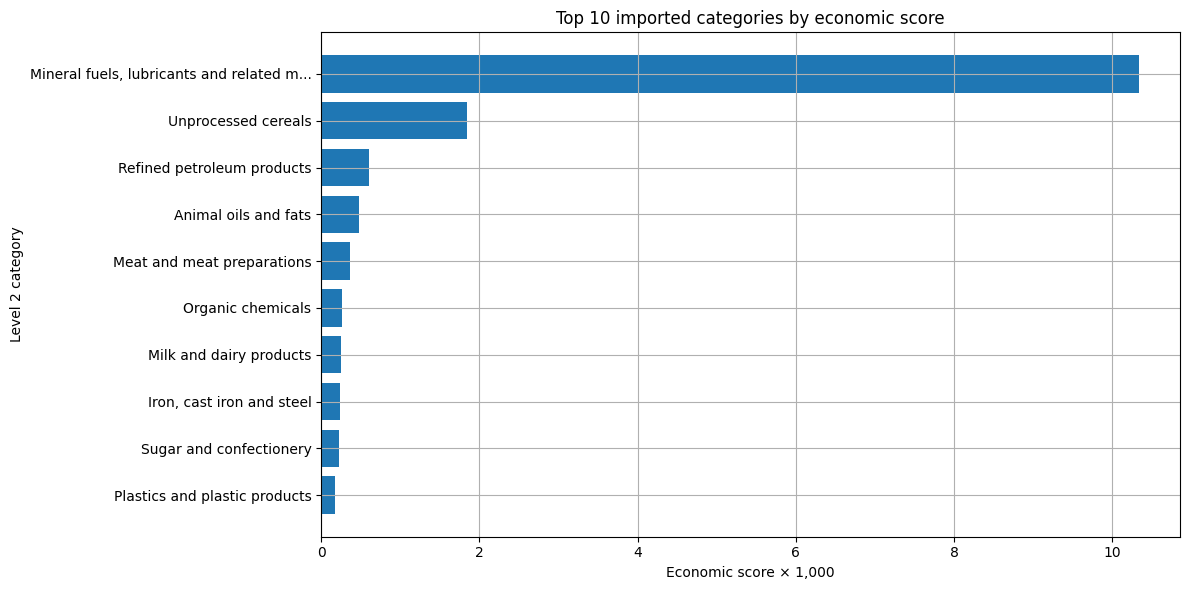

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\top10_economic_score.png


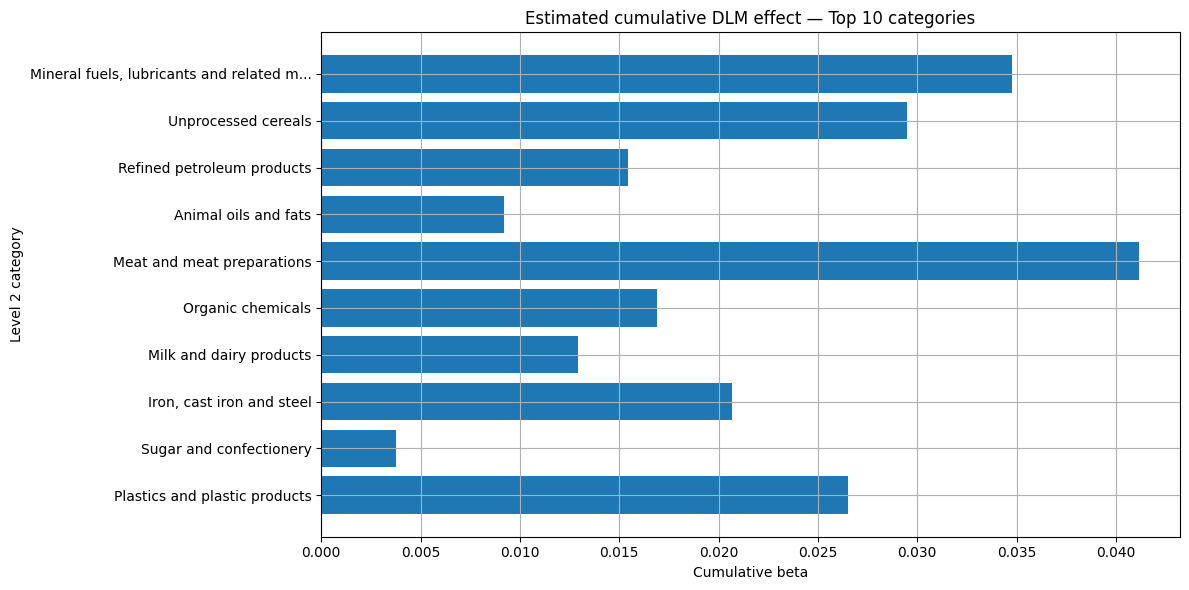

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\top10_cumulative_beta.png


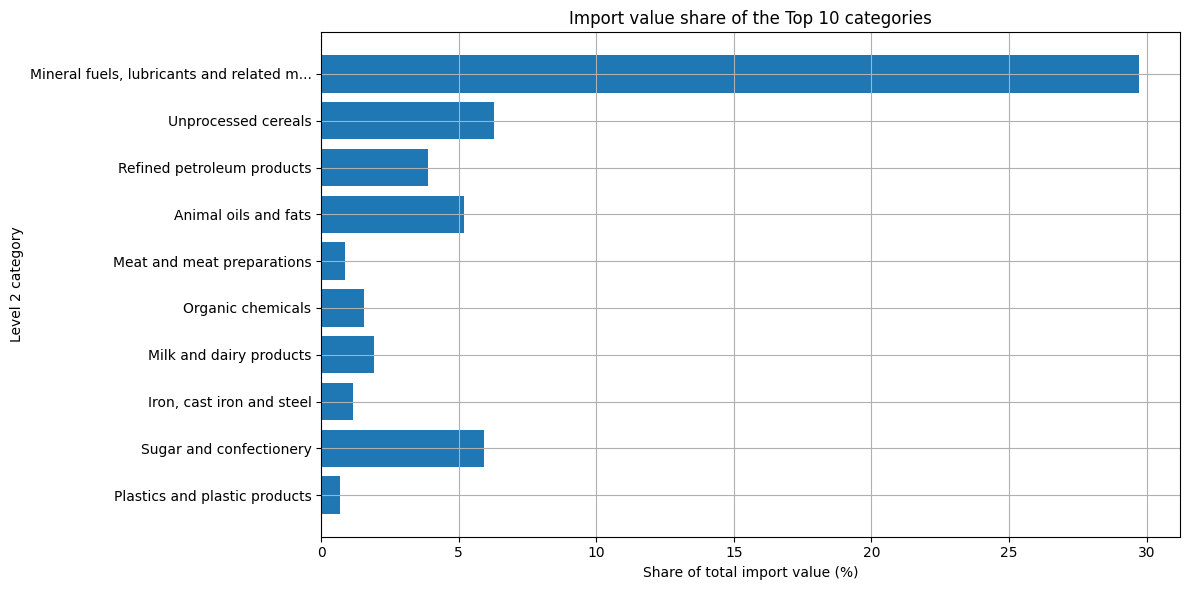

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\top10_import_value_share.png


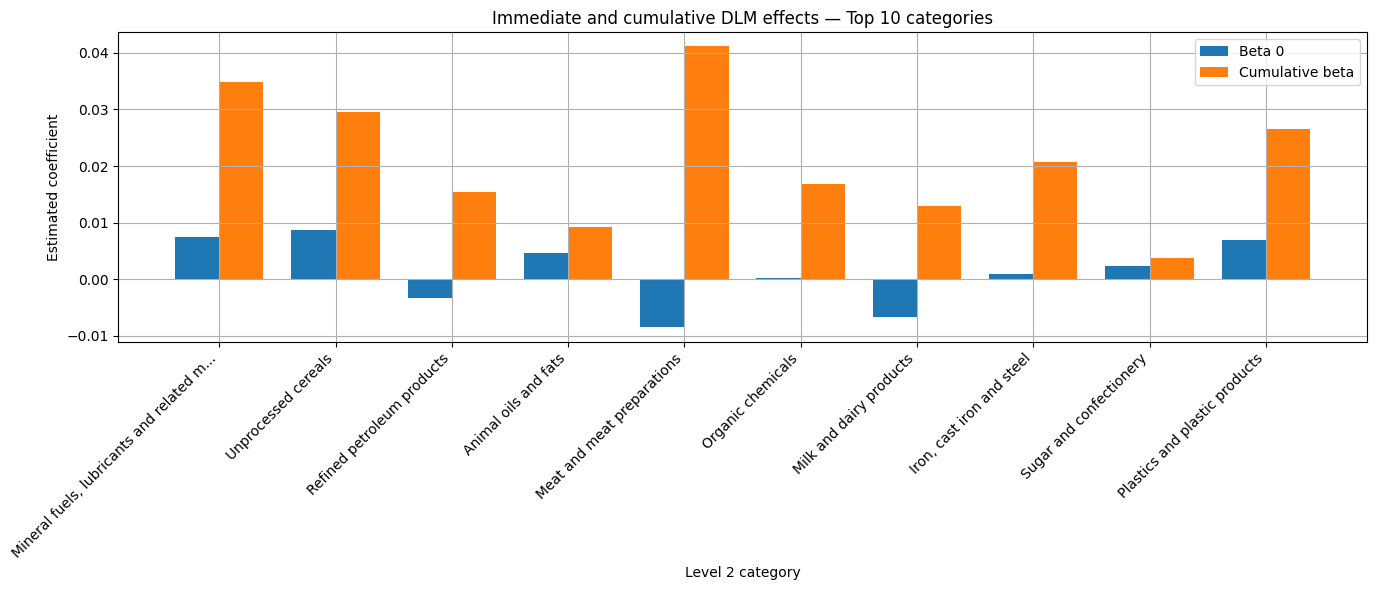

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\top10_immediate_vs_cumulative_effect.png


In [11]:
# %% Cell 10
# ============================================================
# 10. Top 10 economic-score summary and charts
# ============================================================

print("The Level 2 Top 10 is retained as a descriptive DLM result and ranked by economic score.")
print("The Top 10 is not used in the macro ML models to avoid overfitting.")

if len(top10_score) == 0:
    print("No category was selected for the Top 10.")
else:
    top10_score = top10_score.copy()
    top10_score["economic_score_x1000"] = top10_score["economic_score"] * 1000
    top10_score["import_value_share_%"] = top10_score["import_value_share"] * 100

    top10_columns = [
        LEVEL2_COLUMN,
        "economic_score_rank",
        "economic_score",
        "economic_score_x1000",
        "beta_0",
        "cumulative_beta",
        "import_value_share",
        "import_value_share_%",
        "main_lag",
        "joint_test_p_value",
        "adjusted_r2",
    ]

    display_and_save(top10_score[top10_columns], "top10_level2_economic_score_final")

    def shorten_label(text, n=42):
        text = str(text)
        return text if len(text) <= n else text[:n-3] + "..."

    top10_plot = top10_score.sort_values("economic_score", ascending=True).copy()
    top10_plot["short_label"] = top10_plot[LEVEL2_COLUMN].map(translate_level2_label).apply(shorten_label)

    # Chart 1: economic score
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["short_label"], top10_plot["economic_score_x1000"])
    plt.title("Top 10 imported categories by economic score")
    plt.xlabel("Economic score × 1,000")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    output_path = FIGURES_DIR / "top10_economic_score.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

    # Chart 2: cumulative effect (cumulative_beta)
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["short_label"], top10_plot["cumulative_beta"])
    plt.title("Estimated cumulative DLM effect — Top 10 categories")
    plt.xlabel("Cumulative beta")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    output_path = FIGURES_DIR / "top10_cumulative_beta.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

    # Chart 3: share of import value
    plt.figure(figsize=(12, 6))
    plt.barh(top10_plot["short_label"], top10_plot["import_value_share_%"])
    plt.title("Import value share of the Top 10 categories")
    plt.xlabel("Share of total import value (%)")
    plt.ylabel("Level 2 category")
    plt.tight_layout()
    output_path = FIGURES_DIR / "top10_import_value_share.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

    # Chart 4: comparison of beta_0 and cumulative_beta
    top10_plot2 = top10_score.sort_values("economic_score", ascending=False).copy()
    top10_plot2["short_label"] = top10_plot2[LEVEL2_COLUMN].map(translate_level2_label).apply(shorten_label)
    x = np.arange(len(top10_plot2))
    bar_width = 0.38
    plt.figure(figsize=(14, 6))
    plt.bar(x - bar_width/2, top10_plot2["beta_0"], width=bar_width, label="Beta 0")
    plt.bar(x + bar_width/2, top10_plot2["cumulative_beta"], width=bar_width, label="Cumulative beta")
    plt.title("Immediate and cumulative DLM effects — Top 10 categories")
    plt.xlabel("Level 2 category")
    plt.ylabel("Estimated coefficient")
    plt.xticks(x, top10_plot2["short_label"], rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    output_path = FIGURES_DIR / "top10_immediate_vs_cumulative_effect.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

## 12. ARIMAX and SARIMAX models

Estimate the original statistical models using UVI and exchange-rate lags.

In [12]:
# %% Cell 11
# ============================================================
# 11. ARIMAX / SARIMAX comparison using UVI and the exchange rate
#     Simplified final table for the presentation
# ============================================================

# Important:
# ARIMA without exogenous variables is not tested here.
# The objective is to compare only ARIMAX and SARIMAX
# using the exogenous variables: overall UVI and the exchange rate.
#
# The final table does not retain duplicate metrics
# for inflation and INPC.
# For each metric, only the better value is retained:
# - MAE, RMSE, MAPE: lower is better
# - R2: higher is better
# - Accuracy is excluded because it can be misleading.

def split_train_test(base, features=None):
    train = base[base["date"] < TEST_START_DATE].copy()
    test = base[base["date"] >= TEST_START_DATE].copy()

    if len(test) == 0:
        raise ValueError("No test observation is available. Check TEST_START_DATE.")

    y_train = train["monthly_inflation"]
    y_test = test["monthly_inflation"]

    if features is None:
        return train, test, y_train, y_test, None, None

    return train, test, y_train, y_test, train[features], test[features]


def evaluate_prediction(model_name, train, test, y_test, pred, extra=None):
    starting_inpc = train["INPC_global"].iloc[-1]

    # Reconstruct INPC from predicted inflation
    inpc_pred = reconstruct_inpc(starting_inpc, pred)
    actual_inpc = test["INPC_global"].values

    metrics = calculate_metrics(
        y_test.values,
        np.asarray(pred),
        actual_inpc,
        inpc_pred
    )

    result_row = {
        "model": model_name,
        **metrics
    }

    if extra:
        result_row.update(extra)

    pred_df = pd.DataFrame({
        "date": test["date"].values,
        "actual_INPC": actual_inpc,
        "predicted_INPC": inpc_pred,
        "actual_inflation": y_test.values,
        "predicted_inflation": np.asarray(pred),
    })

    return result_row, pred_df


# ------------------------------------------------------------
# Function used to retain only the better metric value
# ------------------------------------------------------------

def best_value(row, col_inflation, col_inpc, direction="min"):
    inflation_value = row[col_inflation] if col_inflation in row.index else np.nan
    inpc_value = row[col_inpc] if col_inpc in row.index else np.nan

    if pd.isna(inflation_value) and pd.isna(inpc_value):
        return np.nan

    if pd.isna(inflation_value):
        return inpc_value

    if pd.isna(inpc_value):
        return inflation_value

    if direction == "min":
        return min(inflation_value, inpc_value)

    if direction == "max":
        return max(inflation_value, inpc_value)

    return np.nan


# ------------------------------------------------------------
# Fixed orders retained to keep the final code stable and fast
# ------------------------------------------------------------

ORDER_ARIMAX = (1, 0, 1)
SEASONAL_ORDER_ARIMAX = (0, 0, 0, 0)

ORDER_SARIMAX = (1, 0, 1)
SEASONAL_ORDER_SARIMAX = (0, 0, 1, 12)


statistical_results = []
statistical_predictions = {}

base_stats = base_macro_model.copy()

train, test, y_train, y_test, X_train, X_test = split_train_test(
    base_stats,
    features_macro
)


# ============================================================
# ARIMAX: inflation/INPC with ARMA dynamics, UVI, and the exchange rate
# ============================================================

try:
    model_arimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER_ARIMAX,
        seasonal_order=SEASONAL_ORDER_ARIMAX,
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )

    res_arimax = model_arimax.fit(disp=False, maxiter=200)

    pred_arimax_values = res_arimax.get_forecast(
        steps=len(test),
        exog=X_test
    ).predicted_mean.values

    arimax_result, pred_df_arimax = evaluate_prediction(
        "ARIMAX_UVI_EXCHANGE",
        train,
        test,
        y_test,
        pred_arimax_values,
        extra={
            "order": ORDER_ARIMAX,
            "seasonal_order": SEASONAL_ORDER_ARIMAX,
            "AIC": res_arimax.aic,
            "BIC": res_arimax.bic,
            "input_features": len(features_macro),
            "training_observations": len(train),
            "test_observations": len(test),
        }
    )

    statistical_results.append(arimax_result)
    statistical_predictions["ARIMAX_UVI_EXCHANGE"] = pred_df_arimax

except Exception as e:
    print("No ARIMAX model could be estimated:", e)


# ============================================================
# SARIMAX: ARIMAX with annual seasonality
# ============================================================

try:
    model_sarimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER_SARIMAX,
        seasonal_order=SEASONAL_ORDER_SARIMAX,
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )

    res_sarimax = model_sarimax.fit(disp=False, maxiter=200)

    pred_sarimax_values = res_sarimax.get_forecast(
        steps=len(test),
        exog=X_test
    ).predicted_mean.values

    sarimax_result, pred_df_sarimax = evaluate_prediction(
        "SARIMAX_UVI_EXCHANGE",
        train,
        test,
        y_test,
        pred_sarimax_values,
        extra={
            "order": ORDER_SARIMAX,
            "seasonal_order": SEASONAL_ORDER_SARIMAX,
            "AIC": res_sarimax.aic,
            "BIC": res_sarimax.bic,
            "input_features": len(features_macro),
            "training_observations": len(train),
            "test_observations": len(test),
        }
    )

    statistical_results.append(sarimax_result)
    statistical_predictions["SARIMAX_UVI_EXCHANGE"] = pred_df_sarimax

except Exception as e:
    print("No SARIMAX model could be estimated:", e)


if len(statistical_results) == 0:
    raise RuntimeError("No ARIMAX/SARIMAX statistical model could be estimated.")


# ============================================================
# Single final table with simplified metrics
# ============================================================

statistical_comparison_detailed = pd.DataFrame(statistical_results)

final_rows = []

for _, row in statistical_comparison_detailed.iterrows():

    final_row = {
        "model": row["model"],

        # Retain the better value between inflation and INPC
        "MAE": best_value(
            row,
            "MAE_inflation",
            "MAE_INPC",
            direction="min"
        ),

        "RMSE": best_value(
            row,
            "RMSE_inflation",
            "RMSE_INPC",
            direction="min"
        ),

        "MAPE_%": best_value(
            row,
            "MAPE_inflation_%",
            "MAPE_INPC_%",
            direction="min"
        ),

        "R2": best_value(
            row,
            "R2_inflation",
            "R2_INPC",
            direction="max"
        ),

        "AIC": row["AIC"],
        "BIC": row["BIC"],

        "order": row["order"],
        "seasonal_order": row["seasonal_order"],

        "training_observations": row["training_observations"],
        "test_observations": row["test_observations"],
    }

    final_rows.append(final_row)


statistical_comparison = pd.DataFrame(final_rows)

# Sort the final table by the retained RMSE
statistical_comparison = statistical_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)


# ------------------------------------------------------------
# Save a single final table
# ------------------------------------------------------------

display_and_save(
    statistical_comparison,
    "statistical_model_comparison"
)

best_statistical_model = statistical_comparison.iloc[0]

print(
    "Best statistical model according to the retained RMSE:",
    best_statistical_model["model"]
)

,Model,MAE,RMSE,MAPE (%),R2,AIC,BIC,order,seasonal_order,Training observations,Test observations
0,ARIMAX,0.432864,0.572136,1.415961,0.745294,77.033880,98.912704,"(1, 0, 1)","(0, 0, 0, 0)",56,9
1,SARIMAX,0.410832,0.589120,1.202471,0.744564,70.383447,91.235482,"(1, 0, 1)","(0, 0, 1, 12)",56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\statistical_model_comparison.xlsx
Best statistical model according to the retained RMSE: ARIMAX_UVI_EXCHANGE


## 13. Statistical-model forecasts

Compare actual and predicted INPC and monthly inflation for ARIMAX and SARIMAX.

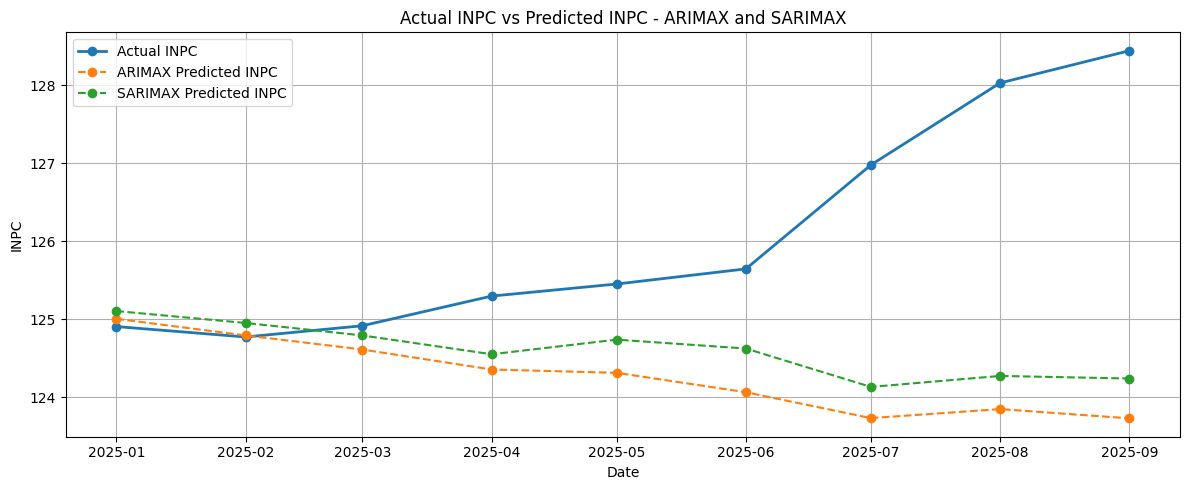

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\actual_vs_predicted_inpc_arimax_sarimax.png


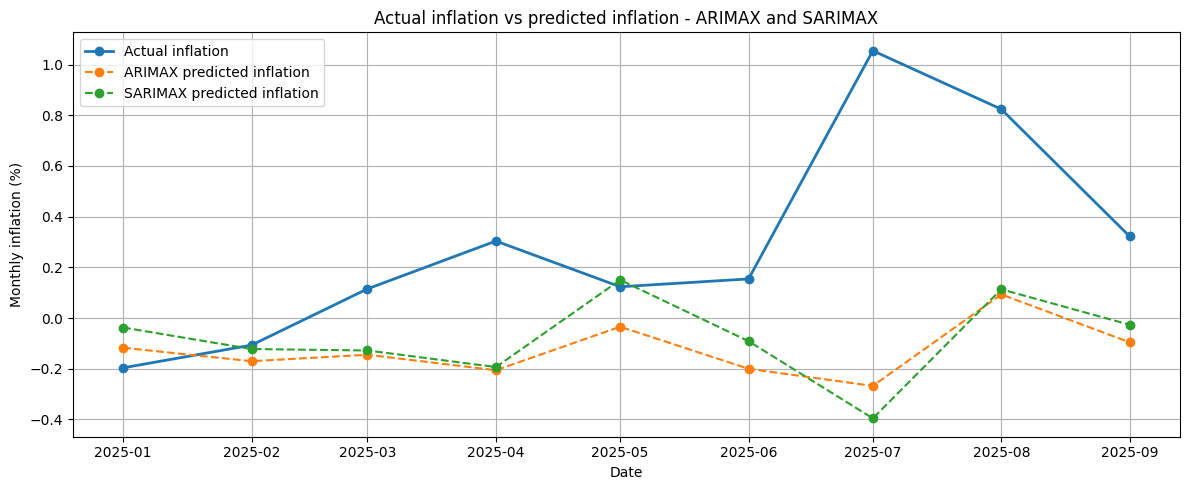

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\actual_vs_predicted_inflation_arimax_sarimax.png


,date,actual_INPC,actual_inflation,ARIMAX_predicted_INPC,SARIMAX_predicted_INPC,ARIMAX_predicted_inflation,SARIMAX_predicted_inflation
0,2025-01-01,124.907260,-0.196386,125.006355,125.106121,-0.117083,-0.037306
1,2025-02-01,124.773955,-0.106780,124.793691,124.953350,-0.170267,-0.122188
2,2025-03-01,124.917772,0.115195,124.613200,124.793591,-0.144737,-0.127937
3,2025-04-01,125.297957,0.303886,124.356954,124.552424,-0.205845,-0.193439
4,2025-05-01,125.452688,0.123414,124.314470,124.739811,-0.034169,0.150335
5,2025-06-01,125.646513,0.154381,124.065875,124.625854,-0.200173,-0.091398
6,2025-07-01,126.978799,1.054762,123.734067,124.133707,-0.267803,-0.395681
7,2025-08-01,128.029590,0.824127,123.849632,124.274649,0.093354,0.113477
8,2025-09-01,128.442654,0.322113,123.731123,124.241552,-0.095734,-0.026636


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\predictions_arimax_sarimax.xlsx


In [13]:
# %% Cell 12
# ============================================================
# 12. ARIMAX / SARIMAX charts
# ============================================================

pred_arimax = statistical_predictions.get("ARIMAX_UVI_EXCHANGE")
pred_sarimax = statistical_predictions.get("SARIMAX_UVI_EXCHANGE")

if pred_arimax is None or pred_sarimax is None:
    print("Warning: ARIMAX or SARIMAX was not estimated. The comparison charts cannot be completed.")
else:
    # Chart 1: Actual INPC vs ARIMAX vs SARIMAX
    plt.figure(figsize=(12, 5))
    plt.plot(pred_arimax["date"], pred_arimax["actual_INPC"], marker="o", linewidth=2, label="Actual INPC")
    plt.plot(pred_arimax["date"], pred_arimax["predicted_INPC"], marker="o", linestyle="--", label="ARIMAX Predicted INPC")
    plt.plot(pred_sarimax["date"], pred_sarimax["predicted_INPC"], marker="o", linestyle="--", label="SARIMAX Predicted INPC")
    plt.title("Actual INPC vs Predicted INPC - ARIMAX and SARIMAX")
    plt.xlabel("Date")
    plt.ylabel("INPC")
    plt.legend()
    plt.tight_layout()
    output_path = FIGURES_DIR / "actual_vs_predicted_inpc_arimax_sarimax.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

    # Chart 2: Actual inflation vs ARIMAX vs SARIMAX
    plt.figure(figsize=(12, 5))
    plt.plot(pred_arimax["date"], pred_arimax["actual_inflation"], marker="o", linewidth=2, label="Actual inflation")
    plt.plot(pred_arimax["date"], pred_arimax["predicted_inflation"], marker="o", linestyle="--", label="ARIMAX predicted inflation")
    plt.plot(pred_sarimax["date"], pred_sarimax["predicted_inflation"], marker="o", linestyle="--", label="SARIMAX predicted inflation")
    plt.title("Actual inflation vs predicted inflation - ARIMAX and SARIMAX")
    plt.xlabel("Date")
    plt.ylabel("Monthly inflation (%)")
    plt.legend()
    plt.tight_layout()
    output_path = FIGURES_DIR / "actual_vs_predicted_inflation_arimax_sarimax.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved:", output_path)

    statistical_predictions_comparison = pred_arimax[["date", "actual_INPC", "actual_inflation"]].copy()
    statistical_predictions_comparison["ARIMAX_predicted_INPC"] = pred_arimax["predicted_INPC"].values
    statistical_predictions_comparison["SARIMAX_predicted_INPC"] = pred_sarimax["predicted_INPC"].values
    statistical_predictions_comparison["ARIMAX_predicted_inflation"] = pred_arimax["predicted_inflation"].values
    statistical_predictions_comparison["SARIMAX_predicted_inflation"] = pred_sarimax["predicted_inflation"].values
    display_and_save(statistical_predictions_comparison, "predictions_arimax_sarimax")

## 14. Machine-learning models

Estimate the original Elastic Net, Ridge, Lasso, Random Forest and Gradient Boosting models, then retain the two best models under the original selection rule.

In [14]:
# %% Cell 13
# ============================================================
# 13. Machine learning models using UVI and the exchange rate
#     Estimate several models, then retain only the top two
#     Simplified final table for the presentation
# ============================================================

# For ML, add one-month-lagged inflation.
# Exclude inflation_lag12 to avoid losing too many observations in a short series.
#
# In the final table:
# - Retain only the top two ML models.
# - Exclude Accuracy because it can be misleading.
# - For each metric, retain the better value between inflation and INPC:
#   MAE, RMSE, MAPE: lower is better
#   R2: higher is better

features_ml_macro = ["inflation_lag1"] + features_macro

base_ml_macro = base_macro.dropna(
    subset=["INPC_global", "monthly_inflation"] + features_ml_macro
).copy()

train_ml, test_ml, y_train_ml, y_test_ml, X_train_ml, X_test_ml = split_train_test(
    base_ml_macro,
    features_ml_macro
)


# ------------------------------------------------------------
# Function used to retain only the better metric value
# ------------------------------------------------------------

def best_value(row, col_inflation, col_inpc, direction="min"):
    inflation_value = row[col_inflation] if col_inflation in row.index else np.nan
    inpc_value = row[col_inpc] if col_inpc in row.index else np.nan

    if pd.isna(inflation_value) and pd.isna(inpc_value):
        return np.nan

    if pd.isna(inflation_value):
        return inpc_value

    if pd.isna(inpc_value):
        return inflation_value

    if direction == "min":
        return min(inflation_value, inpc_value)

    if direction == "max":
        return max(inflation_value, inpc_value)

    return np.nan


# ------------------------------------------------------------
# Machine learning models tested
# ------------------------------------------------------------

ml_models = {
    "Elastic_Net_UVI_EXCHANGE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-4, 2, 80),
            cv=3,
            max_iter=10000,
            random_state=42,
        ))
    ]),

    "Ridge_UVI_EXCHANGE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-4, 4, 100)
        ))
    ]),

    "Lasso_UVI_EXCHANGE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(
            alphas=np.logspace(-4, 2, 80),
            cv=3,
            max_iter=10000,
            random_state=42
        ))
    ]),

    "Random_Forest_UVI_EXCHANGE": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42,
    ),

    "Gradient_Boosting_UVI_EXCHANGE": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42,
    ),
}


ml_results = []
ml_predictions = {}


# ------------------------------------------------------------
# Estimate the ML models
# ------------------------------------------------------------

for model_name, model in ml_models.items():
    try:
        print("Estimating ML model:", model_name)

        model.fit(X_train_ml, y_train_ml)

        pred = model.predict(X_test_ml)

        result_row, pred_df = evaluate_prediction(
            model_name,
            train_ml,
            test_ml,
            y_test_ml,
            pred,
            extra={
                "input_features": len(features_ml_macro),
                "training_observations": len(train_ml),
                "test_observations": len(test_ml),
            }
        )

        ml_results.append(result_row)
        ml_predictions[model_name] = pred_df

    except Exception as e:
        print(f"Model {model_name} could not be estimated: {e}")


if len(ml_results) == 0:
    raise RuntimeError("No machine learning model could be estimated.")


# ============================================================
# Detailed internal table, not saved
# ============================================================

ml_comparison_detailed = pd.DataFrame(ml_results)


# ============================================================
# Simplified final table
# ============================================================

ml_final_rows = []

for _, row in ml_comparison_detailed.iterrows():

    final_row = {
        "model": row["model"],

        # Retain the better value between inflation and INPC
        "MAE": best_value(
            row,
            "MAE_inflation",
            "MAE_INPC",
            direction="min"
        ),

        "RMSE": best_value(
            row,
            "RMSE_inflation",
            "RMSE_INPC",
            direction="min"
        ),

        "MAPE_%": best_value(
            row,
            "MAPE_inflation_%",
            "MAPE_INPC_%",
            direction="min"
        ),

        "R2": best_value(
            row,
            "R2_inflation",
            "R2_INPC",
            direction="max"
        ),

        "training_observations": row["training_observations"],
        "test_observations": row["test_observations"],
    }

    ml_final_rows.append(final_row)


ml_comparison = pd.DataFrame(ml_final_rows)


# ------------------------------------------------------------
# Retain only the top two models according to the selected RMSE
# ------------------------------------------------------------

top2_ml_comparison = ml_comparison.sort_values(
    "RMSE"
).head(2).reset_index(drop=True)


# ------------------------------------------------------------
# Save a single final table
# ------------------------------------------------------------

display_and_save(
    top2_ml_comparison,
    "top2_ml_model_comparison"
)


# ------------------------------------------------------------
# Predictions from the two retained top models
# ------------------------------------------------------------

selected_ml_models = list(top2_ml_comparison["model"])

predictions_ml_top2 = {}

for model_name in selected_ml_models:
    if model_name in ml_predictions:
        predictions_ml_top2[model_name] = ml_predictions[model_name]


best_ml_model = top2_ml_comparison.iloc[0]

print(
    "Best ML model according to the retained RMSE:",
    best_ml_model["model"]
)

print(
    "Two ML models retained:",
    selected_ml_models
)

Estimating ML model: Elastic_Net_UVI_EXCHANGE
Estimating ML model: Ridge_UVI_EXCHANGE
Estimating ML model: Lasso_UVI_EXCHANGE
Estimating ML model: Random_Forest_UVI_EXCHANGE
Estimating ML model: Gradient_Boosting_UVI_EXCHANGE


,Model,MAE,RMSE,MAPE (%),R2,Training observations,Test observations
0,Gradient Boosting,0.268596,0.342975,0.573242,0.948666,56,9
1,Random Forest,0.247272,0.350638,0.365538,0.936762,56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\top2_ml_model_comparison.xlsx
Best ML model according to the retained RMSE: Gradient_Boosting_UVI_EXCHANGE
Two ML models retained: ['Gradient_Boosting_UVI_EXCHANGE', 'Random_Forest_UVI_EXCHANGE']


## 15. Top two machine-learning forecasts

Compare Gradient Boosting and Random Forest forecasts with observed values.

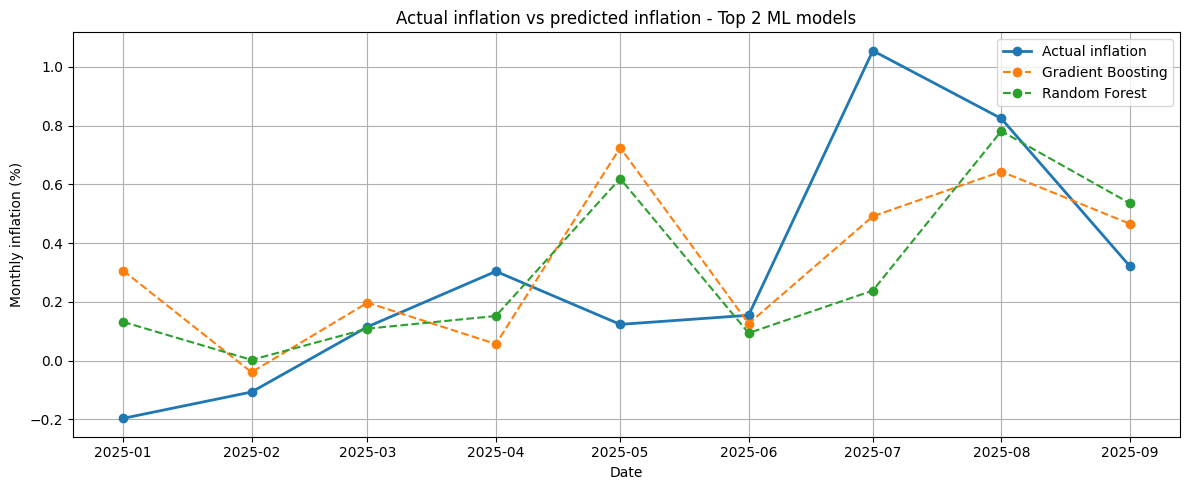

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\ml_top2_inflation.png


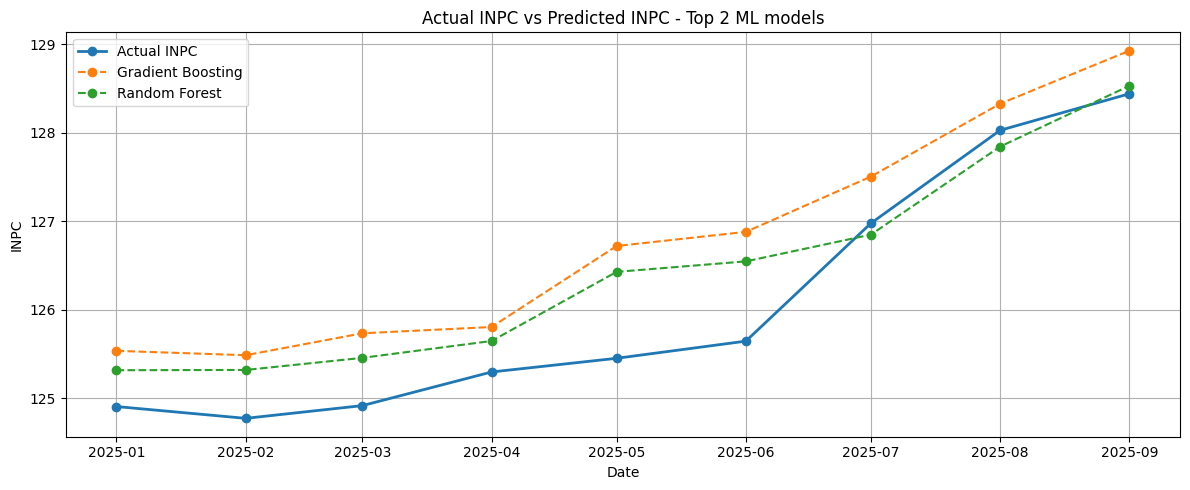

Figure saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures\ml_top2_inpc.png


,date,actual_INPC,actual_inflation,Gradient_Boosting_UVI_EXCHANGE_predicted_INPC,Gradient_Boosting_UVI_EXCHANGE_predicted_inflation,Random_Forest_UVI_EXCHANGE_predicted_INPC,Random_Forest_UVI_EXCHANGE_predicted_inflation
60,2025-01-01,124.907260,-0.196386,125.536889,0.306425,125.317851,0.131792
61,2025-02-01,124.773955,-0.106780,125.487475,-0.039369,125.320950,0.002473
62,2025-03-01,124.917772,0.115195,125.735236,0.197243,125.457491,0.108894
63,2025-04-01,125.297957,0.303886,125.806374,0.056562,125.648332,0.152000
64,2025-05-01,125.452688,0.123414,126.721747,0.724970,126.429538,0.619816
65,2025-06-01,125.646513,0.154381,126.881493,0.125981,126.548117,0.093747
66,2025-07-01,126.978799,1.054762,127.506426,0.491324,126.850396,0.238580
67,2025-08-01,128.029590,0.824127,128.329686,0.643586,127.845350,0.781292
68,2025-09-01,128.442654,0.322113,128.929036,0.465951,128.532297,0.535887


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\predictions_ml_top2.xlsx


In [15]:
# %% Cell 14
# ============================================================
# 14. Charts for the top two ML models
# ============================================================

top2_ml_model_names = top2_ml_comparison["model"].tolist()

# Chart 1: Actual inflation vs the top two ML models
plt.figure(figsize=(12, 5))
plt.plot(test_ml["date"], test_ml["monthly_inflation"], marker="o", linewidth=2, label="Actual inflation")

for model_name in top2_ml_model_names:
    pred_df = ml_predictions[model_name]
    plt.plot(pred_df["date"], pred_df["predicted_inflation"], marker="o", linestyle="--", label=MODEL_LABELS_EN.get(model_name, model_name))

plt.title("Actual inflation vs predicted inflation - Top 2 ML models")
plt.xlabel("Date")
plt.ylabel("Monthly inflation (%)")
plt.legend()
plt.tight_layout()
output_path = FIGURES_DIR / "ml_top2_inflation.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", output_path)

# Chart 2: Actual INPC vs the top two ML models
plt.figure(figsize=(12, 5))
plt.plot(test_ml["date"], test_ml["INPC_global"], marker="o", linewidth=2, label="Actual INPC")

for model_name in top2_ml_model_names:
    pred_df = ml_predictions[model_name]
    plt.plot(pred_df["date"], pred_df["predicted_INPC"], marker="o", linestyle="--", label=MODEL_LABELS_EN.get(model_name, model_name))

plt.title("Actual INPC vs Predicted INPC - Top 2 ML models")
plt.xlabel("Date")
plt.ylabel("INPC")
plt.legend()
plt.tight_layout()
output_path = FIGURES_DIR / "ml_top2_inpc.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved:", output_path)

# Save predictions from the top two ML models in a single file
predictions_ml_top2 = test_ml[["date", "INPC_global", "monthly_inflation"]].copy()
predictions_ml_top2 = predictions_ml_top2.rename(columns={
    "INPC_global": "actual_INPC",
    "monthly_inflation": "actual_inflation",
})

for model_name in top2_ml_model_names:
    pred_df = ml_predictions[model_name].copy()
    predictions_ml_top2[f"{model_name}_predicted_INPC"] = pred_df["predicted_INPC"].values
    predictions_ml_top2[f"{model_name}_predicted_inflation"] = pred_df["predicted_inflation"].values

display_and_save(predictions_ml_top2, "predictions_ml_top2")

## 16. Final model comparison

Combine the two statistical models and the two selected machine-learning models without changing the original results.

In [16]:
# %% Cell 15 
# ============================================================
# Final comparison:
# ARIMAX / SARIMAX + Top 2 Machine Learning
# ============================================================

# After simplifying the tables, the final metric is named RMSE
# rather than RMSE_inflation.
FINAL_SELECTION_METRIC = "RMSE"

# ------------------------------------------------------------
# Statistical-model section: ARIMAX / SARIMAX
# ------------------------------------------------------------

stats_final = statistical_comparison.copy()
stats_final["model_family"] = "Statistical"

# ------------------------------------------------------------
# Machine-learning section: top two ML models
# ------------------------------------------------------------

ml_final = top2_ml_comparison.copy()
ml_final["model_family"] = "Machine Learning"

# ------------------------------------------------------------
# Merge the two model families
# ------------------------------------------------------------

final_comparison = pd.concat(
    [stats_final, ml_final],
    ignore_index=True,
    sort=False
)

# ------------------------------------------------------------
# Final columns to retain
# Some columns exist for ARIMAX/SARIMAX but not for ML
# so create them when they are missing
# ------------------------------------------------------------

final_columns = [
    "model_family",
    "model",
    "MAE",
    "RMSE",
    "MAPE_%",
    "R2",
    "AIC",
    "BIC",
    "order",
    "seasonal_order",
    "training_observations",
    "test_observations",
]

for col in final_columns:
    if col not in final_comparison.columns:
        final_comparison[col] = np.nan

# ------------------------------------------------------------
# Sort by the simplified final metric
# ------------------------------------------------------------

final_comparison = final_comparison.sort_values(
    FINAL_SELECTION_METRIC
).reset_index(drop=True)

final_comparison = final_comparison[final_columns]

# ------------------------------------------------------------
# Save and display the single final table
# Note: display_and_save already displays the table.
# Therefore, do not call display(final_comparison) to avoid duplication.
# ------------------------------------------------------------

display_and_save(
    final_comparison,
    "final_model_comparison"
)

best_overall_model = final_comparison.iloc[0]

print(
    "Best overall model according to",
    FINAL_SELECTION_METRIC,
    ":",
    best_overall_model["model"],
    "- family:",
    best_overall_model["model_family"]
)

,Model family,Model,MAE,RMSE,MAPE (%),R2,AIC,BIC,order,seasonal_order,Training observations,Test observations
0,Machine Learning,Gradient Boosting,0.268596,0.342975,0.573242,0.948666,NaN,NaN,NaN,NaN,56,9
1,Machine Learning,Random Forest,0.247272,0.350638,0.365538,0.936762,NaN,NaN,NaN,NaN,56,9
2,Statistical,ARIMAX,0.432864,0.572136,1.415961,0.745294,77.033880,98.912704,"(1, 0, 1)","(0, 0, 0, 0)",56,9
3,Statistical,SARIMAX,0.410832,0.589120,1.202471,0.744564,70.383447,91.235482,"(1, 0, 1)","(0, 0, 1, 12)",56,9


Saved: C:\Users\hp\Downloads\imported-inflation-mauritania\results\tables\final_model_comparison.xlsx
Best overall model according to RMSE : Gradient_Boosting_UVI_EXCHANGE - family: Machine Learning


## 17. Methodological summary

Summarise the original methodological choices.

In [17]:
# %% Cell 16
# ============================================================
# 16. Final methodological note
# ============================================================

print("Methodological summary:")
print("1) The Level 2 Top 10 is identified using DLM and the economic score, then illustrated with charts.")
print("2) The retained statistical models are ARIMAX and SARIMAX only.")
print("3) Several machine learning models are estimated, but only the top two are retained in the final comparison.")
print("4) The primary selection metric is", SELECTION_METRIC, "because the model first predicts monthly inflation.")
print("5) INPC metrics are retained as complementary information after reconstructing the index.")
print("6) The Top 10 is not used as input to the main ML models to avoid overfitting with a short series.")

Methodological summary:
1) The Level 2 Top 10 is identified using DLM and the economic score, then illustrated with charts.
2) The retained statistical models are ARIMAX and SARIMAX only.
3) Several machine learning models are estimated, but only the top two are retained in the final comparison.
4) The primary selection metric is RMSE_inflation because the model first predicts monthly inflation.
5) INPC metrics are retained as complementary information after reconstructing the index.
6) The Top 10 is not used as input to the main ML models to avoid overfitting with a short series.


## 18. Generated outputs

List the public summary outputs generated by the notebook.

In [18]:
# %% Cell 17
# ============================================================
# 17. Summary of generated files
# ============================================================

print("Processing completed.")
print("Main outputs are stored in:", OUTPUTS_DIR.resolve())
print("Key generated files:")
print("- top10_level2_economic_score_final.xlsx")
print("- top10_economic_score.png")
print("- top10_cumulative_beta.png")
print("- top10_import_value_share.png")
print("- top10_immediate_vs_cumulative_effect.png")
print("- statistical_model_details.xlsx")
print("- statistical_model_comparison.xlsx")
print("- actual_vs_predicted_inpc_arimax_sarimax.png")
print("- actual_vs_predicted_inflation_arimax_sarimax.png")
print("- predictions_arimax_sarimax.xlsx")
print("- machine_learning_model_details.xlsx")
print("- top2_ml_model_details.xlsx")
print("- top2_ml_model_comparison.xlsx")
print("- ml_top2_inflation.png")
print("- ml_top2_inpc.png")
print("- predictions_ml_top2.xlsx")
print("- final_model_comparison.xlsx")
print("- final_model_comparison_rmse.png")

Processing completed.
Main outputs are stored in: C:\Users\hp\Downloads\imported-inflation-mauritania\results\figures
Key generated files:
- top10_level2_economic_score_final.xlsx
- top10_economic_score.png
- top10_cumulative_beta.png
- top10_import_value_share.png
- top10_immediate_vs_cumulative_effect.png
- statistical_model_details.xlsx
- statistical_model_comparison.xlsx
- actual_vs_predicted_inpc_arimax_sarimax.png
- actual_vs_predicted_inflation_arimax_sarimax.png
- predictions_arimax_sarimax.xlsx
- machine_learning_model_details.xlsx
- top2_ml_model_details.xlsx
- top2_ml_model_comparison.xlsx
- ml_top2_inflation.png
- ml_top2_inpc.png
- predictions_ml_top2.xlsx
- final_model_comparison.xlsx
- final_model_comparison_rmse.png
